#### Auto Reloading for External Libraries

In [1]:
import warnings
import numpy as np
from tqdm import tqdm
warnings.filterwarnings('ignore')

In [8]:
# Using this magic command, we turn on auto-reloading for libraries imported by %aimport
%load_ext autoreload
%autoreload 2
%aimport Sub
%aimport Master
%aimport DataPreparation
%aimport DPG_off
%aimport ADMM

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## 1. General Information

In [25]:
# Microgrids data
from DataPreparation import getMGData, getCEMSData
n_mgs = 3
horizon_len = 6
mg_private, mg_public = {}, {}
for mg_id in range(n_mgs):
    mg_private[mg_id], mg_public[mg_id] = getMGData(n_mgs, mg_id, horizon_len)
cems = getCEMSData(n_mgs, mg_public, horizon_len)

In [122]:
# Build models
from Sub import Sub
from Master import Master
f = [Sub(data=mg_private[mg], trade=True, MIP=False) for mg in range(n_mgs)]
g = Master(data=cems)

## 2. No Trade implementation

In [14]:
from Sub import Sub
fy_base = np.array([Sub(data=data_mgs[mg], trade=False, MIP=True) for mg in range(num_mgs)])
for i, f in enumerate(fy_base):
    f.save_solutions(identifier='(NoTrade)')

## 3. ADMM properties and arguments

## 4. Pure ADMM implementation

In [159]:
from ADMM import ADMM_env, ADMM_config, ADMM_run
config = ADMM_config(I=n_mgs, HL=horizon_len)
admm = ADMM_env(f=f, g=g, config=config)

Progress: : 2001it [01:03, 31.73it/s]                        


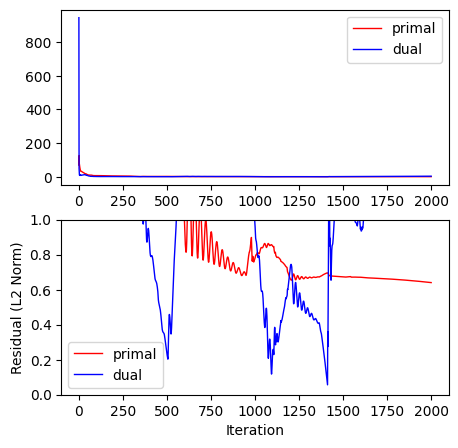

In [160]:
# Reset in case info is not initial
admm.reset()
info, x = ADMM_run(admm_env=admm, max_itr=2000)


In [158]:
info['yhat'][0, 0, 2, :]

array([ 0.06601721,  0.06595096, 25.67031329, 35.36988297, 35.36996353,
        4.74333732])

In [157]:
info['yhat'][1, 2, 0, :]

array([ 0.06601721,  0.06595096, 25.67031329, 35.36988297, 35.36996353,
        4.74333732])

In [163]:
x #info['z1']

array([[0.77003488, 0.7700354 , 0.7586014 , 0.7829851 , 0.78298598,
        0.79085396],
       [0.79943551, 0.79943807, 0.81089446, 0.78651259, 0.78651172,
        0.77858345],
       [0.99999933, 0.99999784, 0.97711988, 0.96577662, 0.9657765 ,
        0.99532411]])

## 4. ADMM with DRL

ADMM rtype: reward type
* RI: Relative Improvement
* RTI: Relative Trend Improvement
ADMM random rho: whether to set initial rho random or based on 2(J_bar - J_local)/epsilon
* False
* True

In [145]:
reward_method = 'RTI'
rand_rho = False
update_rule = 'classic'  # 'hybrid'
drl_identifier = f'DRL-ADMM(reward-{reward_method}, rand-{rand_rho}, update-{update_rule})'

l_init = np.zeros((4, n_mgs, n_mgs, horizon_len))
z_init = 100 * np.ones((4, n_mgs, n_mgs, horizon_len))

admm_args = {
    'prim_eps': 0.05,
    'dual_eps': 0.05,
    'trend_period': 5,
    'trend_weights': [0.1, 0.1, 0.1, 0.2, 0.5],
    'rand_rho': rand_rho,
    'update_rule': update_rule,
    'beta': 0.8,
    'rho_init': 5,
    'l_init': l_init,
    'z_init': z_init,
    'xi': 1e-6,
    'action_min': 1,
    'action_max': 10,
    'action_dim': 1,
    'state_scale': 1,
    'R_conv': 2,
    'reward_method': reward_method,
    'identifier': drl_identifier
}
drl_args = {
    'buffer_capacity': 1000,
    'batch_size': 128,
    'learning_rate': 0.001,
    'gamma': 0.7,
    'noise_init': 2,
    'noise_final': 0.01,
    'identifier': drl_identifier
}
drl_train_args = {
    'episodes': 10,
    'max_itr': 200}

### 4.1. Policy Training

Training Started! r_p and r_d are l2-norm.


Episode 10: 100%|██████████| 200/200 [01:11<00:00,  2.78it/s, Info=Done: False, r_p: 1.6e+00, r_d: 5.5e-01, rho: 1.1e+00]


Training Complete! Duration: 770.41s


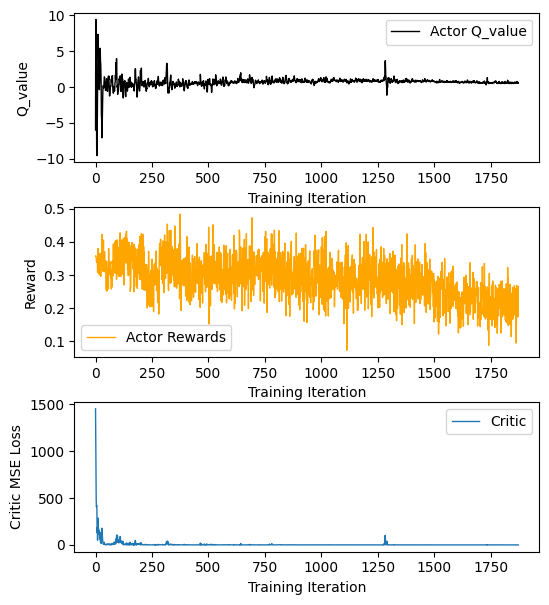

In [146]:
from DPG_off import DPG_Agent
from ADMM_DRL import ADMMEnv

admm_env = ADMMEnv(fy_ip=fy_ip, gz_ip=gz_ip,
                   fy_lp=fy_lp, gz_lp=gz_lp,
                   args=admm_args)

agent = DPG_Agent(env=admm_env, args=drl_args)

agent.train(args=drl_train_args)

In [144]:
# Save actor and critic
agent.save_actor_critic()

Actor and Critic models state dict save successfuly.


### 4.2. Policy Execution

In [143]:
residuals = agent.execute_policy(max_itr=200, identifier=drl_identifier, load=True)

Execution: 100%|██████████| 200/200 [00:33<00:00,  5.99it/s, Info=Done: True, r_p_l2: 3.9e-03, r_d_l2: 9.7e-03, rho: 1.0e+00]


## 5. Reports

In [103]:
from Results import MGResults
from Results import get_cost_table, get_metric_table, get_kpi_table
from Results import plot_trade, plot_load_served

# Results
identifier = admm_args['identifier']
results_before = {i: MGResults(f'(NoTrade)MG({i})', data_mgs[i]) for i in range(num_mgs)}
results_after = {i: MGResults(f'{identifier}MG({i})', data_mgs[i]) for i in range(num_mgs)}

In [104]:

# Cost table
get_cost_table(results_before, results_after, num_mgs, identifier)

# Resilience and Cost reduction
get_metric_table(results_before, results_after, num_mgs, data_alpha, identifier)

# KPI
get_kpi_table(results_after, num_mgs, data_alpha, identifier)

# Trade Plot
plot_trade(results_after, identifier)

# Load Satisfaction Plot
plot_load_served(results_after, 1, identifier)

In [93]:
results_after[0].pi_buy

array([[0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
       [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 3.65970687e-04,
        0.00000000e+00, 0.00000000e+00, 6.53877069e+00, 0.00000000e+00,
        6.06211305e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
        1.72220449e+01, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
        0.00000000e+00, 2.01336809e-04, 0.00000000e+00, 4.99986026e+00],
       [6.80434255e+00, 0.00000000e+00, 0.00000000e+00, 9.51330619e+00,
        0.00000000e+00, 0.00000000e+00, 3.68380900e+01, 0.0000

In [92]:
results_after[2].pi_sell

array([[6.82206781e+00, 0.00000000e+00, 0.00000000e+00, 9.53126664e+00,
        0.00000000e+00, 5.93739628e-03, 3.68566770e+01, 0.00000000e+00,
        1.24436685e+01, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 3.39113969e+01],
       [3.65162671e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
        6.22170022e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
        0.00000000e+00, 0.00000000e+00, 3.54024634e+00, 3.73766417e+00,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 4.50738241e+00,
        0.00000000e+00, 4.81501279e+00, 0.00000000e+00, 0.00000000e+00],
       [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.0000